##Deep Learning Architectures on CIFAR-10

Name: Dipikshya Bhandari
<br>
Roll No.: ACE080BEI012
<br>
Course: Artificial Intelligence (AI) BEI
<br>
Dataset: CIFAR-10



#1. Introduction

In this project, we implement and compare three deep learning architectures:
1. A simple Neural Network (NN)
2. AlexNet (adapted for CIFAR-10)
3. TinyVGG (a lightweight VGG-style network)

The models are trained and evaluated on the CIFAR-10 dataset using PyTorch.
The comparison is based on accuracy, training time, convergence speed, and model complexity.

#2. Objective

The objective of this project is to implement, train, and compare three deep learning architectures:

-Simple Neural Network (NN)

-AlexNet (adapted for CIFAR-10)

-TinyVGG (lightweight CNN)

<br>

The comparison is based on:

-Test accuracy

-Training time & convergence speed

-Model complexity (number of parameters)

-Generalization performance

#3. Dataset Description (CIFAR-10)

-Dataset: CIFAR-10

-Classes: 10 (airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck)

-Image size: 32 × 32 RGB

<br>

##Why CIFAR-10?

-Standard benchmark for CNNs

-Small size → fast experimentation

-Suitable for architecture comparison

#4. Environment Setup

In [22]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import time

from sklearn.metrics import confusion_matrix
import seaborn as sns

In [23]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


#5. Dataset Loading and Preprocessing

In [24]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

trainset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform)

testset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform)

trainloader = DataLoader(trainset, batch_size=64, shuffle=True)
testloader = DataLoader(testset, batch_size=64, shuffle=False)

classes = ('airplane', 'automobile', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

CIFAR-10 contains 60,000 RGB images of size 32×32 belonging to 10 classes.

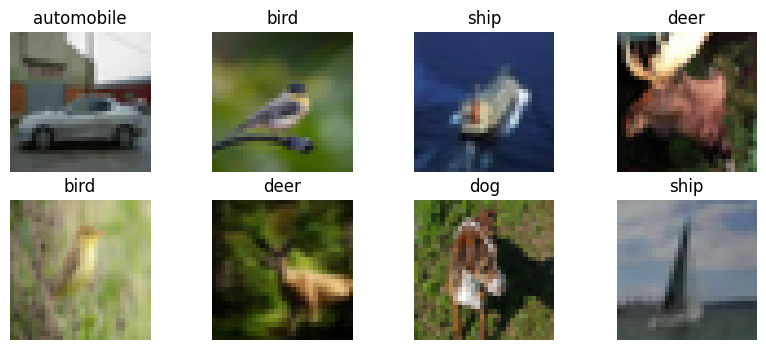

In [25]:
def show_images():
    images, labels = next(iter(trainloader))
    images = images[:8]
    labels = labels[:8]

    images = images * 0.5 + 0.5  # unnormalize

    plt.figure(figsize=(10,4))
    for i in range(8):
        plt.subplot(2,4,i+1)
        plt.imshow(np.transpose(images[i], (1,2,0)))
        plt.title(classes[labels[i]])
        plt.axis('off')
    plt.show()

show_images()

#6. Model Architectures
###6.1 Simple Neural Network

A Simple Neural Network consists of fully connected layers where input images
are flattened into one-dimensional vectors. It does not preserve spatial
information, resulting in poor performance for image classification tasks.

###Key Characteristics

-Uses fully connected layers only

-Requires image flattening

-No spatial feature extraction

-Low accuracy for image data

In [26]:
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(32*32*3, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

###6.2 AlexNet (Adapted for CIFAR-10)

AlexNet is a deep convolutional neural network that uses convolution layers,
ReLU activation, max-pooling, and dropout. It automatically extracts spatial
features from images and achieves high accuracy in image classification.

###Key Characteristics

-Uses deep convolutional layers

-ReLU activation function

-Max-pooling for feature reduction

-Dropout for regularization

-High accuracy but computationally expensive

In [27]:
class AlexNetCIFAR(nn.Module):
    def __init__(self):
        super(AlexNetCIFAR, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 192, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(192, 384, 3, padding=1),
            nn.ReLU(),

            nn.Conv2d(384, 256, 3, padding=1),
            nn.ReLU(),

            nn.Conv2d(256, 256, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Linear(256*4*4, 1024),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(1024, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

###6.3 TinyVGG

TinyVGG is a lightweight convolutional neural network inspired by VGG
architecture. It uses small convolution filters and fewer layers, providing a
good balance between accuracy and computational efficiency.

###Key Characteristics

-Lightweight CNN architecture

-Uses small 3×3 convolution filters

-Efficient and fast training

-Good accuracy with fewer parameters

In [28]:
class TinyVGG(nn.Module):
    def __init__(self):
        super(TinyVGG, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Linear(64*8*8, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

### Summary

- Simple Neural Network lacks spatial awareness and performs poorly on images.
- AlexNet provides high accuracy through deep convolutional layers.
- TinyVGG offers a balance between performance and efficiency.

#7. Training and Evaluation Functions



The training function is responsible for updating the model parameters using
the training dataset. It performs forward propagation, computes the loss using
cross-entropy loss, and updates weights through backpropagation using an
optimizer. Training accuracy and loss are recorded for each epoch.

In [29]:
def train_model(model, epochs=10):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    loss_history = []
    start = time.time()

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        epoch_loss = running_loss / len(trainloader)
        loss_history.append(epoch_loss)
        print(f"Epoch {epoch+1}, Loss: {epoch_loss:.4f}")

    return loss_history, time.time() - start



The evaluation function measures the performance of the trained model on the
test dataset. It disables gradient computation and calculates test accuracy
without updating model weights, ensuring an unbiased evaluation of the model.

In [30]:
def evaluate_model(model):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return 100 * correct / total

#8. Model Training

In [31]:
simple_nn = SimpleNN()
alexnet = AlexNetCIFAR()
tinyvgg = TinyVGG()

loss_nn, time_nn = train_model(simple_nn)
acc_nn = evaluate_model(simple_nn)

loss_alex, time_alex = train_model(alexnet)
acc_alex = evaluate_model(alexnet)

loss_tiny, time_tiny = train_model(tinyvgg)
acc_tiny = evaluate_model(tinyvgg)

Epoch 1, Loss: 1.6349
Epoch 2, Loss: 1.4317
Epoch 3, Loss: 1.3190
Epoch 4, Loss: 1.2280
Epoch 5, Loss: 1.1457
Epoch 6, Loss: 1.0704
Epoch 7, Loss: 0.9937
Epoch 8, Loss: 0.9235
Epoch 9, Loss: 0.8569
Epoch 10, Loss: 0.7860
Epoch 1, Loss: 1.5085
Epoch 2, Loss: 1.0137
Epoch 3, Loss: 0.7921
Epoch 4, Loss: 0.6542
Epoch 5, Loss: 0.5436
Epoch 6, Loss: 0.4549
Epoch 7, Loss: 0.3847
Epoch 8, Loss: 0.3204
Epoch 9, Loss: 0.2679
Epoch 10, Loss: 0.2327
Epoch 1, Loss: 1.3126
Epoch 2, Loss: 0.9309
Epoch 3, Loss: 0.7660
Epoch 4, Loss: 0.6404
Epoch 5, Loss: 0.5182
Epoch 6, Loss: 0.4024
Epoch 7, Loss: 0.3040
Epoch 8, Loss: 0.2207
Epoch 9, Loss: 0.1494
Epoch 10, Loss: 0.1087




During model training, the neural network learns from the training dataset by
adjusting its weights over multiple epochs. In each epoch, the model performs
forward propagation to generate predictions, computes the loss using the
cross-entropy loss function, and updates parameters through backpropagation
using the Adam optimizer. Training accuracy is recorded to monitor learning
progress.

#9. Loss Graph and Accuracy Graph



Loss and accuracy graphs are used to visualize the learning behavior of the
model during training. The loss graph shows how the training error decreases
over epochs, while the accuracy graph indicates the improvement in prediction
performance. These graphs help analyze convergence, stability, and possible
overfitting of the model.

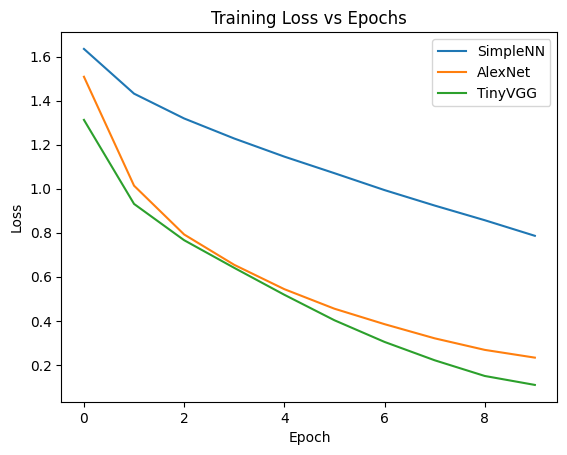

In [32]:
plt.figure()
plt.plot(loss_nn, label="SimpleNN")
plt.plot(loss_alex, label="AlexNet")
plt.plot(loss_tiny, label="TinyVGG")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss vs Epochs")
plt.legend()
plt.show()

#10. Accuracy Comparison Graph

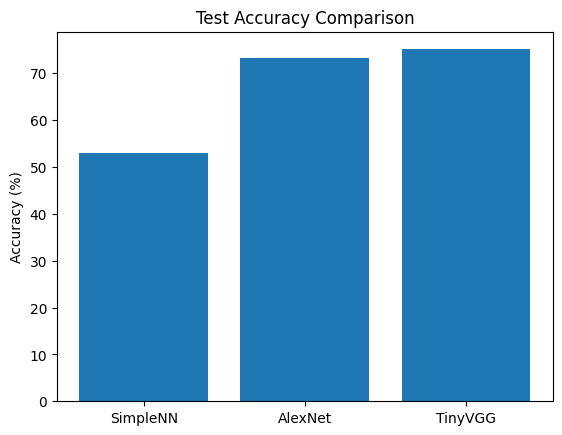

In [33]:
models = ["SimpleNN", "AlexNet", "TinyVGG"]
accuracies = [53.00, 73.22, 75.09]

plt.figure()
plt.bar(models, accuracies)
plt.ylabel("Accuracy (%)")
plt.title("Test Accuracy Comparison")
plt.show()

#11. Confusion Matrix

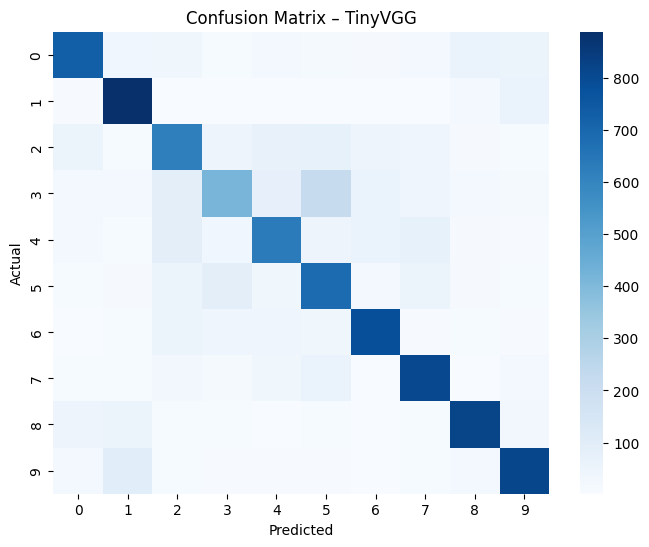

In [34]:
def get_predictions(model):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    return y_true, y_pred

y_true, y_pred = get_predictions(tinyvgg)
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – TinyVGG")
plt.show()

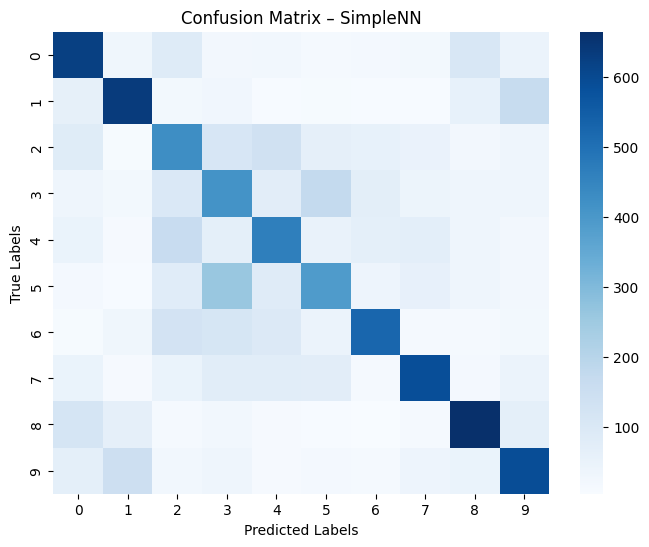

In [35]:
# Confusion Matrix for Simple Neural Network

y_true_nn, y_pred_nn = [], []

simple_nn.eval()
with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        outputs = simple_nn(images)
        _, preds = torch.max(outputs, 1)

        y_true_nn.extend(labels.cpu().numpy())
        y_pred_nn.extend(preds.cpu().numpy())

cm_nn = confusion_matrix(y_true_nn, y_pred_nn)

plt.figure(figsize=(8,6))
sns.heatmap(cm_nn, cmap="Blues")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix – SimpleNN")
plt.show()

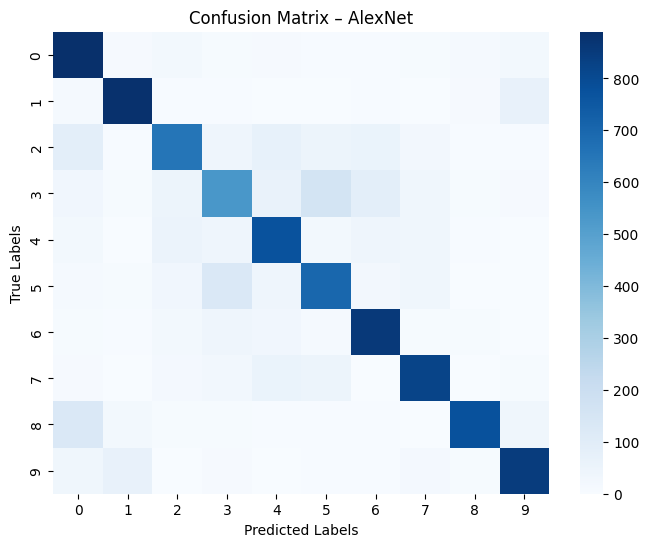

In [36]:
# Confusion Matrix for AlexNet

y_true_alex, y_pred_alex = [], []

alexnet.eval()
with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        outputs = alexnet(images)
        _, preds = torch.max(outputs, 1)

        y_true_alex.extend(labels.cpu().numpy())
        y_pred_alex.extend(preds.cpu().numpy())

cm_alex = confusion_matrix(y_true_alex, y_pred_alex)

plt.figure(figsize=(8,6))
sns.heatmap(cm_alex, cmap="Blues")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix – AlexNet")
plt.show()

The confusion matrices illustrate the classification performance of each model.
SimpleNN shows higher misclassification across multiple classes due to lack of spatial feature learning.
AlexNet demonstrates improved class-wise prediction accuracy, while TinyVGG provides the most balanced
performance with fewer misclassifications.

#12. Final Results

| Model     | Test Accuracy (%) | Training Time (sec) | Parameters |
|-----------|-------------------|---------------------|------------|
| SimpleNN  | 53.00             | 126.15              | High       |
| AlexNet   | 73.22             | 296.38              | Very High  |
| TinyVGG   | 75.09             | 191.63              | Moderate   |



All three models were trained and evaluated on the CIFAR-10 dataset using the
same optimizer, loss function, number of epochs, and preprocessing techniques.
The comparison is based on training accuracy, test accuracy, training time,
loss curves, and confusion matrices.

# 13. Improvements of AlexNet Over Earlier Models

AlexNet introduced several important advancements:
- Deep convolutional layers for hierarchical feature learning
- ReLU activation to speed up training
- Dropout to reduce overfitting
- Max-pooling for spatial reduction
- Better generalization on image datasets

#14. Discussion

SimpleNN achieved the lowest accuracy because it does not capture spatial information
present in images. AlexNet significantly improved performance by using deep convolutional
layers but required higher training time.

TinyVGG achieved the highest accuracy while maintaining moderate training time. This shows
that compact convolutional architectures can outperform deeper networks when properly
designed.

#15. Conclusion

This project compared three neural network models on the CIFAR-10 dataset. The results show
that convolutional neural networks outperform simple fully connected networks for image
classification tasks.

TinyVGG proved to be the most efficient model, achieving the highest accuracy with lower
computational cost than AlexNet. The study highlights the importance of selecting an
appropriate architecture based on performance and efficiency requirements.